<a href="https://colab.research.google.com/github/07ashu97912-hub/ML-projects/blob/main/linear_regression/advertising_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
df=pd.read_csv('/content/drive/MyDrive/ml data/advertising.csv')
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [5]:
df.corr()

,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.901208
Radio,0.054809,1.000000,0.354104,0.349631
Newspaper,0.056648,0.354104,1.000000,0.157960
Sales,0.901208,0.349631,0.157960,1.000000


In [6]:
x=df.drop(columns=['Sales'])
y=df['Sales']

from sklearn.model_selection import train_test_split

xtrain,xtest,ytrain,ytest = train_test_split(x,y,test_size=0.2,random_state=32)

In [7]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()

xtrain=ss.fit_transform(xtrain)
xtest=ss.transform(xtest)

In [8]:
# from sklearn.decomposition import PCA

# pca=PCA(n_components=2)

# xtrain = pca.fit_transform(xtrain,ytrain)
# xtest = pca.transform(xtest)

In [9]:
from sklearn.linear_model import LinearRegression

lr=LinearRegression()

lr.fit(xtrain,ytrain)

LinearRegression()

In [10]:
prediction = lr.predict(xtest)

In [11]:
from sklearn.metrics import r2_score,mean_squared_error
from sklearn.model_selection import cross_val_score

crossval = cross_val_score(lr,xtrain,ytrain,scoring='r2',cv=10)
print(crossval)
print(np.mean(crossval))

[0.8428232  0.79795351 0.93884292 0.94313508 0.93028819 0.83710868
 0.86955503 0.93927519 0.80231909 0.89251902]
0.8793819908722916


In [12]:
lr.coef_ , lr.intercept_

(array([ 4.5618973 ,  1.65593736, -0.0177195 ]),
 np.float64(15.282499999999999))

In [13]:
from sklearn.linear_model import Ridge , Lasso
from sklearn.model_selection import GridSearchCV

In [14]:
param={'alpha':[0,0.01,0.1,0.2,0.5,0.8,1,5,10,25,50,100,250,500,750,1000]}
ridge=Ridge()
clf = GridSearchCV(estimator=ridge , param_grid=param , cv=10)
clf.fit(xtrain,ytrain)

GridSearchCV(cv=10, estimator=Ridge(),
             param_grid={'alpha': [0, 0.01, 0.1, 0.2, 0.5, 0.8, 1, 5, 10, 25,
                                   50, 100, 250, 500, 750, 1000]})

In [15]:
print(clf.best_estimator_ , clf.best_score_)

Ridge(alpha=5) 0.8798485854017912


In [16]:
results_df = pd.DataFrame(clf.cv_results_)
print(results_df[['param_alpha', 'mean_test_score', 'std_test_score']])

    param_alpha  mean_test_score  std_test_score
0          0.00         0.879382        0.054535
1          0.01         0.879385        0.054527
2          0.10         0.879414        0.054458
3          0.20         0.879446        0.054382
4          0.50         0.879534        0.054158
5          0.80         0.879613        0.053939
6          1.00         0.879661        0.053797
7          5.00         0.879849        0.051430
8         10.00         0.878264        0.049585
9         25.00         0.864794        0.048566
10        50.00         0.826524        0.051328
11       100.00         0.734937        0.054082
12       250.00         0.513752        0.056709
13       500.00         0.315815        0.075839
14       750.00         0.212488        0.092299
15      1000.00         0.149627        0.103777


In [17]:
lasso = Lasso()
param={'alpha':[0,0.01,0.1,0.2,0.5,0.8,1,5,10,25,50,100,250,500,750,1000]}
clf = GridSearchCV(estimator=lasso , param_grid=param , cv=10 )
clf.fit(xtrain,ytrain)

GridSearchCV(cv=10, estimator=Lasso(),
             param_grid={'alpha': [0, 0.01, 0.1, 0.2, 0.5, 0.8, 1, 5, 10, 25,
                                   50, 100, 250, 500, 750, 1000]})

In [18]:
print(clf.best_estimator_ , clf.best_params_)

Lasso(alpha=0.1) {'alpha': 0.1}


In [19]:
results_df = pd.DataFrame(clf.cv_results_)
print(results_df[['param_alpha', 'mean_test_score', 'std_test_score']])

    param_alpha  mean_test_score  std_test_score
0          0.00         0.879382        0.054535
1          0.01         0.879882        0.053973
2          0.10         0.882151        0.049653
3          0.20         0.881776        0.047099
4          0.50         0.870655        0.043653
5          0.80         0.846031        0.041877
6          1.00         0.822113        0.040798
7          5.00        -0.105354        0.157328
8         10.00        -0.105354        0.157328
9         25.00        -0.105354        0.157328
10        50.00        -0.105354        0.157328
11       100.00        -0.105354        0.157328
12       250.00        -0.105354        0.157328
13       500.00        -0.105354        0.157328
14       750.00        -0.105354        0.157328
15      1000.00        -0.105354        0.157328


In [20]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('poly',PolynomialFeatures()),
    ('scalar',StandardScaler()),
    ('linear',LinearRegression())
])
params = {'poly__degree':[2,3,4,5,6] , 'poly__include_bias':[True,False]}

clf = GridSearchCV(estimator=pipeline , param_grid=params , cv=10 , scoring='r2',n_jobs=-1)

clf.fit(xtrain,ytrain)

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('poly', PolynomialFeatures()),
                                       ('scalar', StandardScaler()),
                                       ('linear', LinearRegression())]),
             n_jobs=-1,
             param_grid={'poly__degree': [2, 3, 4, 5, 6],
                         'poly__include_bias': [True, False]},
             scoring='r2')

In [21]:
print(clf.best_params_['poly__degree'] , '\n' , clf.best_estimator_, '\n' , clf.best_score_)

2 
 Pipeline(steps=[('poly', PolynomialFeatures()), ('scalar', StandardScaler()),
                ('linear', LinearRegression())]) 
 0.924067888288643


In [22]:
results_df = pd.DataFrame(clf.cv_results_)
print(results_df[['param_poly__degree', 'mean_test_score', 'std_test_score']])

   param_poly__degree  mean_test_score  std_test_score
0                   2         0.924068        0.035548
1                   2         0.924068        0.035548
2                   3         0.911095        0.043927
3                   3         0.911095        0.043927
4                   4         0.549695        0.726048
5                   4         0.549695        0.726048
6                   5        -0.889224        3.740304
7                   5        -0.889224        3.740304
8                   6      -248.125587      586.440105
9                   6      -248.125587      586.440105


In [23]:
model = clf.best_estimator_

In [24]:
prediction = model.predict(xtest)
r2_score(ytest,prediction)

0.9088900338837635

In [34]:
pipeline2=Pipeline([
    ('poly',PolynomialFeatures()),
    ('scale',StandardScaler()),
    ('ridge',Ridge())
])

metrics = {'poly__degree':[2,3,4,5],
           'poly__include_bias':[True,False],
           'ridge__alpha':[0.1,1,5,10,100,500]}

clf = GridSearchCV(estimator=pipeline2 , param_grid=metrics , cv=10 , scoring='r2')
clf.fit(xtrain , ytrain)

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('poly', PolynomialFeatures()),
                                       ('scale', StandardScaler()),
                                       ('ridge', Ridge())]),
             param_grid={'poly__degree': [2, 3, 4, 5],
                         'poly__include_bias': [True, False],
                         'ridge__alpha': [0.1, 1, 5, 10, 100, 500]},
             scoring='r2')

In [35]:
print(clf.best_params_ , clf.best_score_)

{'poly__degree': 2, 'poly__include_bias': True, 'ridge__alpha': 1} 0.9242294835329705


In [36]:
model = clf.best_estimator_

In [37]:
model.fit(xtrain,ytrain)
pred = clf.predict(xtest)
r2_score(ytest,pred)

0.9083287767834072

In [38]:
search_results = pd.DataFrame(clf.cv_results_)
print(search_results[['param_poly__degree','param_poly__include_bias','param_ridge__alpha','mean_test_score']])

    param_poly__degree  param_poly__include_bias  param_ridge__alpha  \
0                    2                      True                 0.1   
1                    2                      True                 1.0   
2                    2                      True                 5.0   
3                    2                      True                10.0   
4                    2                      True               100.0   
5                    2                      True               500.0   
6                    2                     False                 0.1   
7                    2                     False                 1.0   
8                    2                     False                 5.0   
9                    2                     False                10.0   
10                   2                     False               100.0   
11                   2                     False               500.0   
12                   3                      True                

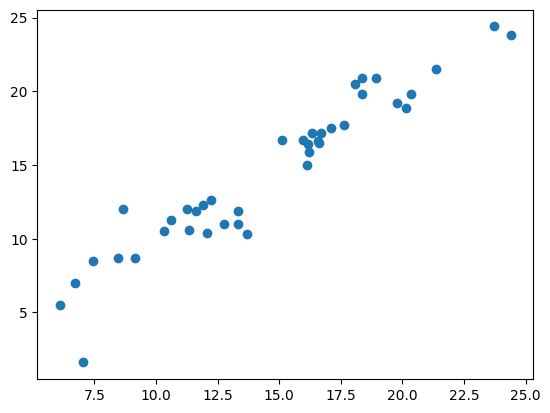

In [40]:
plt.scatter(pred,ytest)

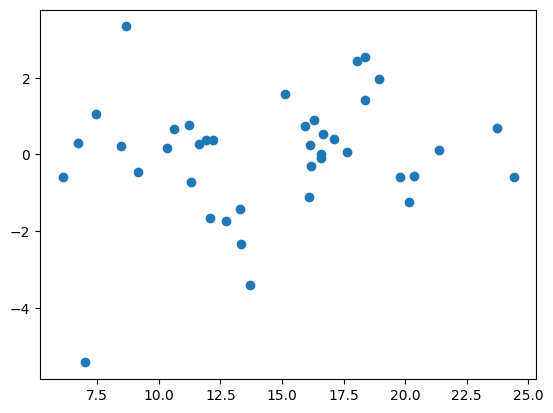

In [42]:
plt.scatter(pred , ytest-pred)